In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [ ]:
concrete = pd.read_csv("data/concrete+slump+test/slump_test.data")

concrete.rename(columns={'No':'id',
    'Compressive Strength (28-day)(Mpa)':'Comp_Strength',
    'FLOW(cm)': 'Flow'},
    inplace=True)

lm_flow_water = ols("Flow ~ Water", data = concrete).fit()

print(lm_flow_water.summary())

print(lm_flow_water.conf_int())
lm_flow_water.r


                            OLS Regression Results                            
Dep. Variable:                   Flow   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     67.18
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           8.10e-13
Time:                        17:39:16   Log-Likelihood:                -414.60
No. Observations:                 103   AIC:                             833.2
Df Residuals:                     101   BIC:                             838.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -58.7276     13.286     -4.420      0.0

                            OLS Regression Results                            
Dep. Variable:                   Flow   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     49.17
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           1.35e-15
Time:                        22:14:44   Log-Likelihood:                -405.59
No. Observations:                 103   AIC:                             817.2
Df Residuals:                     100   BIC:                             825.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -50.2666     12.387     -4.058      0.0

np.float64(0.4857331923793702)

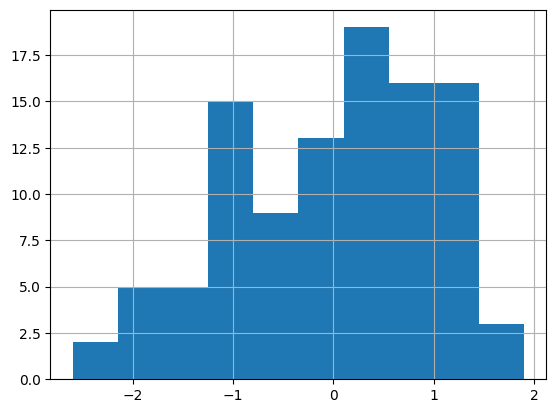

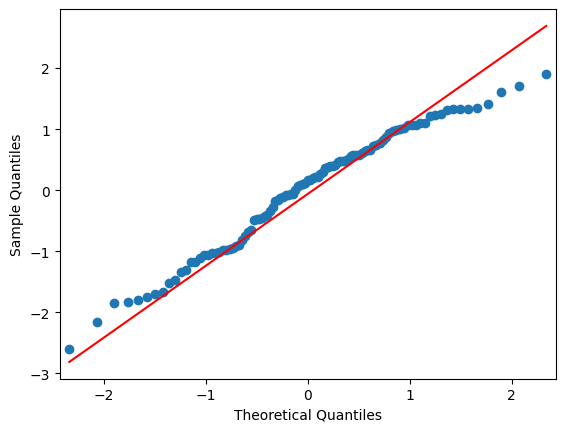

In [ ]:
lm_flow_water_slag = ols("Flow ~ Water + Slag", data = concrete).fit()

print(lm_flow_water_slag.summary())

r_s = pd.Series(lm_flow_water_slag.resid_pearson)

r_s.hist()

sm.qqplot(r_s, line="q")

print(lm_flow_water_slag.rsquared_adj)
print(lm_flow_water_slag.rsquared)